In [34]:
library(dplyr)
library(readr)
library(ggplot2)

In [35]:
energy <- "electricity"
monthlyPath <- paste0("../../curated/", energy, "/gold_monthly_",    energy, ".csv")

In [36]:
# Monthly
energyMonthly    <- read_csv(monthlyPath, show_col_types = FALSE) %>%
                    mutate(year_month = factor(paste(year, month, sep = "-")))
weatherMonthly   <- read_csv("../../curated/weather/gold_monthly_weather.csv", show_col_types = FALSE) %>%
                    mutate(year_month = factor(paste(year, month, sep = "-")))

In [37]:
dfMonthly <- weatherMonthly %>%
    left_join(energyMonthly,   by = c("year", "month"), suffix = c("", "_energy")) %>%
    select(
        year, 
        month,
        year_month,
        avg_temp,
        avg_dewpt_temp,
        avg_rel_hum_pct,
        avg_wind_dir,
        avg_wind_spd,
        avg_visib,
        avg_stn_press,
        avg_hmdx,
        avg_wind_chill,
        consumption
    )

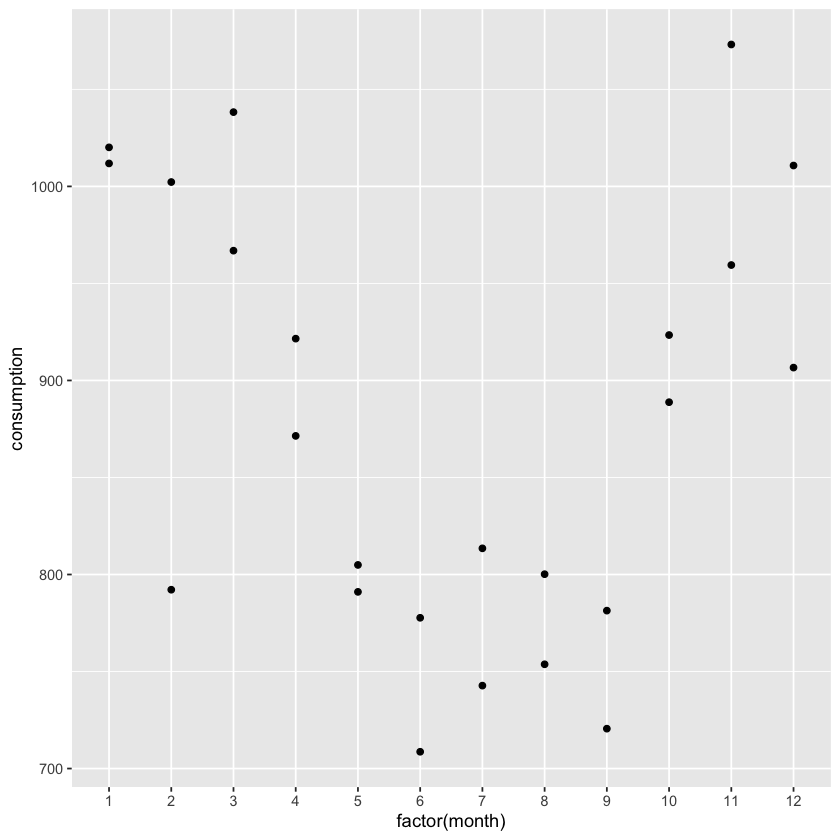

In [38]:
ggplot(dfMonthly, aes(x = factor(month), y = consumption)) +
    geom_point()

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


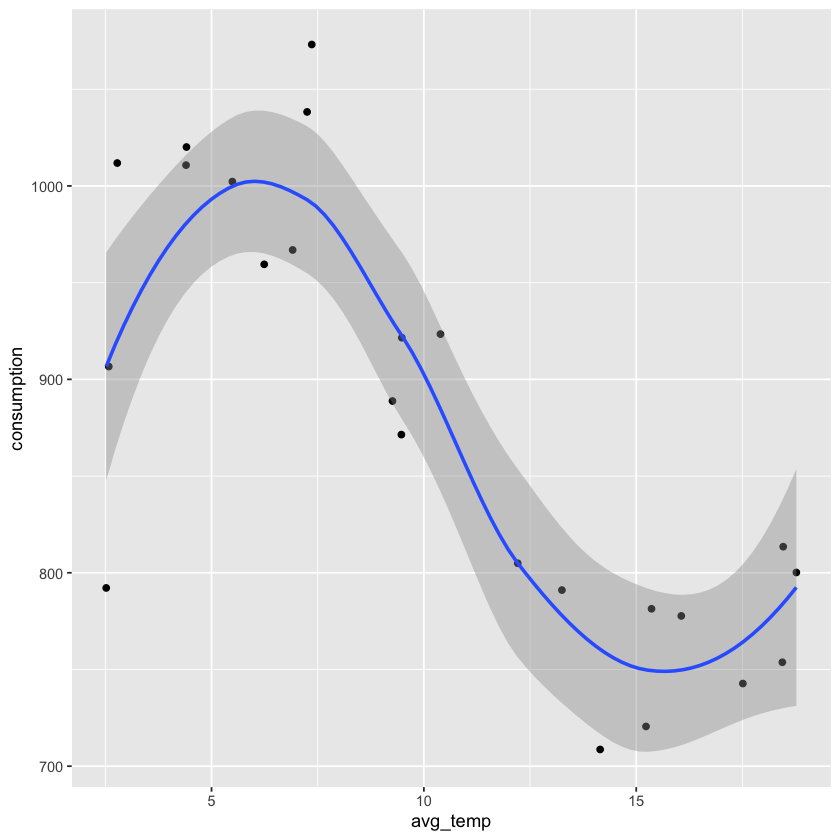

In [39]:
ggplot(dfMonthly, aes(x = avg_temp, y = consumption)) +
    geom_point() +
    geom_smooth()

In [40]:
library(mgcv)
library(ranger)

In [61]:

fmla        <- "consumption ~ month + avg_temp + avg_dewpt_temp"
model_rf    <- ranger(as.formula(fmla), dfMonthly, num.trees = 500, respect.unordered.factors = "order")
model_lin   <- lm(as.formula(fmla), data = dfMonthly)
model_gam   <- gam(consumption ~ s(month) + s(avg_temp), family = "gaussian", data = dfMonthly)

In [62]:
model_rf
#summary(model_lin)
#summary(model_gam)

Ranger result

Call:
 ranger(as.formula(fmla), dfMonthly, num.trees = 500, respect.unordered.factors = "order") 

Type:                             Regression 
Number of trees:                  500 
Sample size:                      24 
Number of independent variables:  3 
Mtry:                             1 
Target node size:                 5 
Variable importance mode:         none 
Splitrule:                        variance 
OOB prediction error (MSE):       4153.445 
R squared (OOB):                  0.672295 

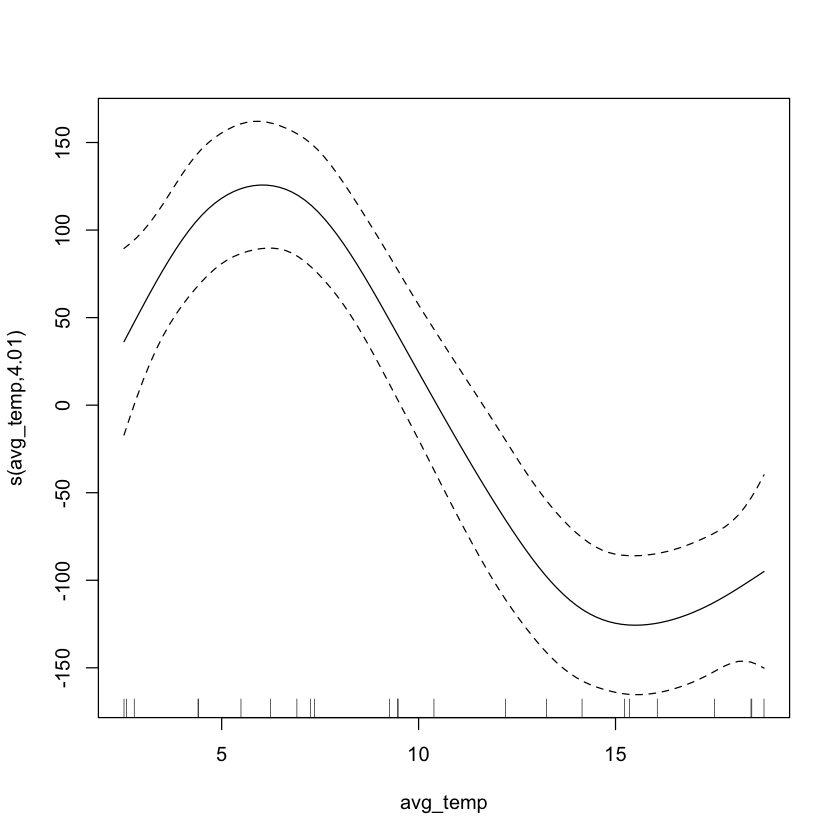

In [43]:
plot(model_gam)